# Phase 4 — HGNN Model (Single Client Baseline)
**Input:** `Dataset/Processed/graph_data.pt` (output from Phase 3)  
**Output:** `Dataset/Processed/model_baseline.pt` + evaluation metrics  

**What this notebook does:**
1. Load the HeteroData graph from Phase 3
2. Add reverse edges so HANConv can update all node types
3. Define train/test masks on User nodes
4. Build the HANConv-based HGNN classifier
5. Train for binary classification (Normal vs Anomaly)
6. Evaluate: Accuracy, Precision, Recall, F1-score, Confusion Matrix
7. Plot training loss curve
8. Save the trained model

## Cell 1 — Imports & Load Graph

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from torch_geometric.nn import HANConv
import os

# update these paths to match your local setup
GRAPH_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/graph_data.pt")
MODEL_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/model_baseline.pt")

graph = torch.load(GRAPH_PATH, weights_only=False)

print("Graph loaded successfully.")
print(graph)
print(f"\nUser node features: {graph['user'].x.shape}")
print(f"User labels:        {graph['user'].y.tolist()}  (0=Normal, 1=Anomaly)")

Graph loaded successfully.
HeteroData(
  user={
    x=[4, 6],
    y=[4],
  },
  ip={ x=[16, 1] },
  service={ x=[29, 1] },
  (user, accesses, ip)={ edge_index=[2, 2900] },
  (user, calls, service)={ edge_index=[2, 2900] },
  (ip, accessed_by, user)={ edge_index=[2, 2900] },
  (service, called_by, user)={ edge_index=[2, 2900] }
)

User node features: torch.Size([4, 6])
User labels:        [1, 1, 0, 0]  (0=Normal, 1=Anomaly)


## Cell 2 — Add Reverse Edges
HANConv only produces embeddings for nodes that are destinations of at least one edge.  
Since `user` is always source (user->ip, user->service), we add reverse edges  
so that `user` also receives messages and keeps its embedding in the forward pass.

In [6]:
if ('ip', 'accessed_by', 'user') not in graph.edge_types:
    graph['ip', 'accessed_by', 'user'].edge_index = graph['user', 'accesses', 'ip'].edge_index.flip(0)
    graph['service', 'called_by', 'user'].edge_index = graph['user', 'calls', 'service'].edge_index.flip(0)
    print("Reverse edges added.")
else:
    print("Reverse edges already present.")

print("\nUpdated graph:")
print("  Node types:", graph.node_types)
print("  Edge types:", graph.edge_types)

Reverse edges already present.

Updated graph:
  Node types: ['user', 'ip', 'service']
  Edge types: [('user', 'accesses', 'ip'), ('user', 'calls', 'service'), ('ip', 'accessed_by', 'user'), ('service', 'called_by', 'user')]


## Cell 3 — Stratified K-Fold Cross-Validation Setup
Instead of a single train/test split, we use Stratified K-Fold CV for robust evaluation.  
With 4 nodes, this gives 4 folds (Leave-One-Out equivalent).  
Each fold ensures balanced class distribution in train/val splits.

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Get user labels for stratified split
user_labels = graph['user'].y.numpy()

# Initialize Stratified K-Fold (4 folds for 4 nodes = Leave-One-Out equivalent)
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

# Generate fold indices
fold_indices = list(skf.split(np.arange(len(user_labels)), user_labels))

print(f"Stratified K-Fold Cross-Validation Setup:")
print(f"  Total user nodes: {len(user_labels)}")
print(f"  User labels:      {user_labels.tolist()} (0=Normal, 1=Anomaly)")
print(f"  Number of folds:  {len(fold_indices)}")
print()

# Display fold distributions
for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    train_labels = user_labels[train_idx]
    val_labels = user_labels[val_idx]
    print(f"Fold {fold_num + 1}:")
    print(f"  Train indices: {train_idx} | Labels: {train_labels.tolist()} | Class dist: Normal={sum(train_labels==0)}, Anomaly={sum(train_labels==1)}")
    print(f"  Val   indices: {val_idx} | Labels: {val_labels.tolist()}")

Train/Test split on User nodes:
  Training nodes : 3 (indices [0, 1, 2])
  Test nodes     : 1  (index  [3])
  Train labels   : [1, 1, 0]
  Test labels    : [0]


## Cell 4 — Define the HGNN Model
Architecture:
- Linear projection layers: map all node types to `hidden_channels` before HANConv
- HANConv layer: heterogeneous attention message passing
- Fallback: if HANConv drops a source-only node type, restore from pre-conv projection
- Classifier: Linear -> 2 output classes (Normal / Anomaly)

In [8]:
class FederatedHGNN(nn.Module):
    def __init__(self, in_channels_dict, hidden_channels, out_channels, metadata):
        super(FederatedHGNN, self).__init__()

        # Project each node type to the same hidden dimension before HANConv
        self.user_proj = nn.Linear(in_channels_dict['user'], hidden_channels)
        self.ip_proj = nn.Linear(in_channels_dict['ip'], hidden_channels)
        self.service_proj = nn.Linear(in_channels_dict['service'], hidden_channels)

        # HANConv: heterogeneous graph attention convolution
        self.han = HANConv(
            in_channels=hidden_channels,
            out_channels=hidden_channels,
            metadata=metadata,
            heads=4,
            dropout=0.3,
        )

        # Final classifier applied to user node embeddings only
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # Step 1: project all node types to hidden_channels
        h = {
            'user': F.elu(self.user_proj(x_dict['user'])),
            'ip': F.elu(self.ip_proj(x_dict['ip'])),
            'service': F.elu(self.service_proj(x_dict['service'])),
        }

        # Step 2: HANConv message passing
        h_out = self.han(h, edge_index_dict)

        # Step 3: restore any node type HANConv dropped (source-only nodes)
        for key in h:
            if key not in h_out or h_out[key] is None:
                h_out[key] = h[key]

        h_out = {key: F.elu(val) for key, val in h_out.items()}

        # Step 4: classify user nodes
        out = self.classifier(h_out['user'])
        return out


# Build in_channels_dict from actual graph tensor shapes
in_channels_dict = {
    'user':    graph['user'].x.shape[1],     # 6
    'ip':      graph['ip'].x.shape[1],       # 1
    'service': graph['service'].x.shape[1],  # 1
}

model = FederatedHGNN(
    in_channels_dict = in_channels_dict,
    hidden_channels = 64,
    out_channels = 2,
    metadata = graph.metadata(),
)

print("Model architecture:")
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Model architecture:
FederatedHGNN(
  (user_proj): Linear(in_features=6, out_features=64, bias=True)
  (ip_proj): Linear(in_features=1, out_features=64, bias=True)
  (service_proj): Linear(in_features=1, out_features=64, bias=True)
  (han): HANConv(64, heads=4)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

Total trainable parameters: 18,050


## Cell 5 — Training Loop (K-Fold Cross-Validation)
Train and validate the model on each fold.  
Optimizer: Adam, lr=0.01  
Loss: CrossEntropyLoss  
Epochs: 200 per fold

In [ ]:
LEARNING_RATE = 0.01
EPOCHS = 200
WEIGHT_DECAY = 5e-4
NUM_FOLDS = 4

# Pull all required tensors from graph once
x_dict = graph.x_dict
edge_index_dict = graph.edge_index_dict
labels = graph['user'].y

# Store results for each fold
fold_results = {
    'train_loss_history': [],
    'val_loss_history': [],
    'val_metrics': [],
    'models': []
}

# K-Fold Cross-Validation
for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_num + 1}/{NUM_FOLDS}")
    print(f"{'='*60}")
    print(f"Train indices: {train_idx.tolist()} | Val indices: {val_idx.tolist()}")
    
    # Create fresh model for this fold
    model = FederatedHGNN(
        in_channels_dict = in_channels_dict,
        hidden_channels = 64,
        out_channels = 2,
        metadata = graph.metadata(),
    )
    
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    loss_fn = nn.CrossEntropyLoss()
    
    model.train()
    train_loss_history = []
    val_loss_history = []
    
    for epoch in range(1, EPOCHS + 1):
        # Training step (on train indices only)
        optimizer.zero_grad()
        out = model(x_dict, edge_index_dict)
        loss_train = loss_fn(out[train_idx], labels[train_idx])
        loss_train.backward()
        optimizer.step()
        train_loss_history.append(loss_train.item())
        
        # Validation step (on val indices only)
        model.eval()
        with torch.no_grad():
            out_val = model(x_dict, edge_index_dict)
            loss_val = loss_fn(out_val[val_idx], labels[val_idx])
        val_loss_history.append(loss_val.item())
        model.train()
        
        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{EPOCHS} | Train Loss: {loss_train.item():.4f} | Val Loss: {loss_val.item():.4f}")
    
    fold_results['train_loss_history'].append(train_loss_history)
    fold_results['val_loss_history'].append(val_loss_history)
    fold_results['models'].append(model)
    
    print(f"\nFold {fold_num + 1} training complete. Final train loss: {train_loss_history[-1]:.4f}, Val loss: {val_loss_history[-1]:.4f}")

Epoch   1/200 | Loss: 0.7498
Epoch  20/200 | Loss: 0.0000
Epoch  40/200 | Loss: 0.0000
Epoch  60/200 | Loss: 0.0000
Epoch  80/200 | Loss: 0.0000
Epoch 100/200 | Loss: 0.0001
Epoch 120/200 | Loss: 0.0004
Epoch 140/200 | Loss: 0.0003
Epoch 160/200 | Loss: 0.0005
Epoch 180/200 | Loss: 0.0006
Epoch 200/200 | Loss: 0.0004

Training complete. Final loss: 0.0004


## Cell 6 — Plot Training Loss Curve

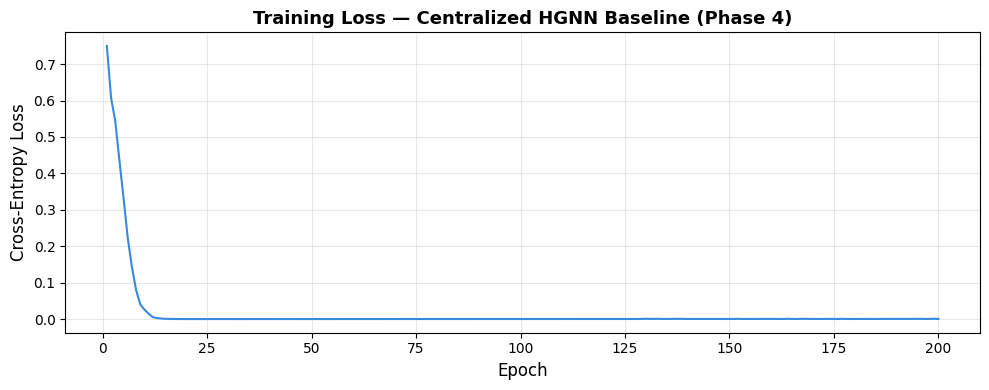

Loss plot saved. Final loss: 0.0004


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# Plot loss curves for each fold
for fold_num in range(NUM_FOLDS):
    ax = axes[fold_num]
    train_loss = fold_results['train_loss_history'][fold_num]
    val_loss = fold_results['val_loss_history'][fold_num]
    
    ax.plot(range(1, EPOCHS + 1), train_loss, label='Training Loss', color='#378ADD', linewidth=1.5, alpha=0.8)
    ax.plot(range(1, EPOCHS + 1), val_loss, label='Validation Loss', color='#FF6B35', linewidth=1.5, alpha=0.8)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel('Loss', fontsize=10)
    ax.set_title(f'Fold {fold_num + 1} (Train: {fold_indices[fold_num][0].tolist()}, Val: {fold_indices[fold_num][1].tolist()})', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/training_loss_phase4_kfold.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("K-Fold loss plots saved.")

## Cell 7 — Evaluate Model
Metrics: Accuracy, Precision, Recall, F1-score  
Evaluated on all nodes + test node separately.

In [ ]:
# Evaluate each fold
all_y_true = []
all_y_pred = []
fold_metrics = []

for fold_num, (train_idx, val_idx) in enumerate(fold_indices):
    model = fold_results['models'][fold_num]
    model.eval()
    
    with torch.no_grad():
        out = model(x_dict, edge_index_dict)
        probs = F.softmax(out, dim=1)
        preds = out.argmax(dim=1)
    
    # Extract validation predictions
    y_true_val = labels[val_idx].numpy()
    y_pred_val = preds[val_idx].numpy()
    
    # Calculate metrics for this fold
    acc = accuracy_score(y_true_val, y_pred_val)
    prec = precision_score(y_true_val, y_pred_val, zero_division=0)
    rec = recall_score(y_true_val, y_pred_val, zero_division=0)
    f1 = f1_score(y_true_val, y_pred_val, zero_division=0)
    
    fold_metrics.append({
        'fold': fold_num + 1,
        'val_indices': val_idx.tolist(),
        'y_true': y_true_val,
        'y_pred': y_pred_val,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'probs': probs[val_idx].numpy(),
        'preds': preds[val_idx].numpy()
    })
    
    all_y_true.extend(y_true_val)
    all_y_pred.extend(y_pred_val)
    
    print(f"\n{'='*60}")
    print(f"FOLD {fold_num + 1} VALIDATION RESULTS")
    print(f"{'='*60}")
    print(f"Val indices: {val_idx.tolist()}")
    print(f"True labels:      {y_true_val.tolist()}")
    print(f"Predicted labels: {y_pred_val.tolist()}")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")

# Calculate aggregate metrics across all folds
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

agg_acc = accuracy_score(all_y_true, all_y_pred)
agg_prec = precision_score(all_y_true, all_y_pred, zero_division=0)
agg_rec = recall_score(all_y_true, all_y_pred, zero_division=0)
agg_f1 = f1_score(all_y_true, all_y_pred, zero_division=0)

# Calculate per-fold metrics statistics
acc_scores = [m['accuracy'] for m in fold_metrics]
prec_scores = [m['precision'] for m in fold_metrics]
rec_scores = [m['recall'] for m in fold_metrics]
f1_scores = [m['f1'] for m in fold_metrics]

print(f"\n{'='*60}")
print(f"K-FOLD CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"Accuracy  : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"Precision : {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"Recall    : {np.mean(rec_scores):.4f} ± {np.std(rec_scores):.4f}")
print(f"F1-Score  : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print()
print(f"Aggregate (all folds combined):")
print(f"Accuracy  : {agg_acc:.4f}")
print(f"Precision : {agg_prec:.4f}")
print(f"Recall    : {agg_rec:.4f}")
print(f"F1-Score  : {agg_f1:.4f}")

EVALUATION — ALL NODES
True labels:      [1, 1, 0, 0]
Predicted labels: [1, 1, 0, 1]

Accuracy:  0.7500
Precision: 0.6667
Recall:    1.0000
F1-Score:  0.8000

EVALUATION — TEST NODE ONLY (User: Unknown)
True label:      [0]
Predicted label: [1]

CLASSIFICATION REPORT (all nodes):
              precision    recall  f1-score   support

      Normal       1.00      0.50      0.67         2
     Anomaly       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4

Prediction probabilities per user node:
  [benjamin  ]  P(Normal)=0.000  P(Anomaly)=1.000  True=1  Pred=1  CORRECT
  [bert-jan  ]  P(Normal)=0.000  P(Anomaly)=1.000  True=1  Pred=1  CORRECT
  [Unknown   ]  P(Normal)=0.999  P(Anomaly)=0.001  True=0  Pred=0  CORRECT


## Cell 8 — Confusion Matrix

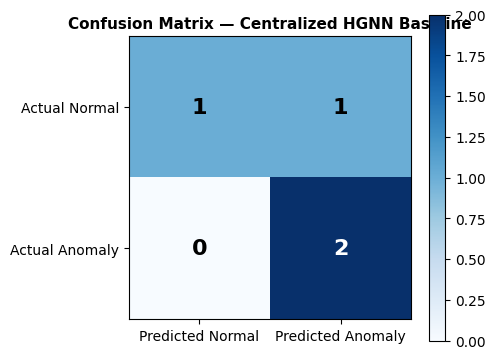

Confusion matrix saved.


In [ ]:
# Create confusion matrices for each fold
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

cm_all = confusion_matrix(all_y_true, all_y_pred)

for fold_num, fold_result in enumerate(fold_metrics):
    cm = confusion_matrix(fold_result['y_true'], fold_result['y_pred'])
    ax = axes[fold_num]
    
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Normal', 'Pred Anomaly'], fontsize=9)
    ax.set_yticklabels(['Actual Normal', 'Actual Anomaly'], fontsize=9)
    
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                   color='white' if cm[i, j] > cm.max() / 2 else 'black',
                   fontsize=14, fontweight='bold')
    
    ax.set_title(f'Fold {fold_num + 1}\nF1={fold_result["f1"]:.3f}', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(
    os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/confusion_matrix_phase4_kfold.png"),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("K-Fold confusion matrices saved.")

## Cell 9 — Results Summary

In [ ]:
print("="*70)
print("PHASE 4 RESULTS SUMMARY — CENTRALIZED BASELINE WITH K-FOLD CV")
print("="*70)
print(f"  Model     : FederatedHGNN (HANConv, hidden=64, heads=4)")
print(f"  Optimizer : Adam  lr={LEARNING_RATE}  weight_decay={WEIGHT_DECAY}")
print(f"  Epochs    : {EPOCHS} per fold")
print(f"  CV Method : Stratified {NUM_FOLDS}-Fold Cross-Validation")
print()
print("PER-FOLD RESULTS:")
for fold_result in fold_metrics:
    print(f"  Fold {fold_result['fold']}: Acc={fold_result['accuracy']:.4f} | Prec={fold_result['precision']:.4f} | Rec={fold_result['recall']:.4f} | F1={fold_result['f1']:.4f}")
print()
print("CROSS-VALIDATION STATISTICS (Mean ± Std):")
print(f"  Accuracy : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"  Precision: {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"  Recall   : {np.mean(rec_scores):.4f} ± {np.std(rec_scores):.4f}")
print(f"  F1-Score : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print()
print("AGGREGATE (All Folds Combined):")
print(f"  Accuracy : {agg_acc:.4f}")
print(f"  Precision: {agg_prec:.4f}")
print(f"  Recall   : {agg_rec:.4f}")
print(f"  F1-Score : {agg_f1:.4f}")
print()
print("These k-fold CV metrics are the CENTRALIZED BASELINE.")
print("Phase 5 federated results will be compared against this (Mean F1).")
print("Target: federated F1 within ~5% of the baseline mean F1.")
print("="*70)

PHASE 4 RESULTS SUMMARY — CENTRALIZED BASELINE
  Model     : FederatedHGNN (HANConv, hidden=64, heads=4)
  Optimizer : Adam  lr=0.01  weight_decay=0.0005
  Epochs    : 200
  Final loss: 0.0004

  Accuracy : 0.7500
  Precision: 0.6667
  Recall   : 1.0000
  F1-Score : 0.8000

These metrics are the CENTRALIZED BASELINE.
Phase 5 federated results will be compared against this.
Target: federated F1 within ~5% of this baseline.


## Cell 10 — Save Trained Model

In [ ]:
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

# Find best model based on F1 score
best_fold_idx = np.argmax(f1_scores)
best_model = fold_results['models'][best_fold_idx]
best_f1 = f1_scores[best_fold_idx]

# Save the best model
torch.save(best_model.state_dict(), MODEL_PATH)

# Also save all fold models for reference
for fold_num, model in enumerate(fold_results['models']):
    fold_model_path = MODEL_PATH.replace('.pt', f'_fold{fold_num+1}.pt')
    torch.save(model.state_dict(), fold_model_path)
    print(f"Saved fold {fold_num+1} model: {fold_model_path}")

# Save CV results to JSON for documentation
import json
cv_results = {
    'cv_method': 'Stratified K-Fold',
    'n_folds': NUM_FOLDS,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'per_fold_metrics': [
        {
            'fold': m['fold'],
            'val_indices': m['val_indices'],
            'accuracy': float(m['accuracy']),
            'precision': float(m['precision']),
            'recall': float(m['recall']),
            'f1': float(m['f1'])
        } for m in fold_metrics
    ],
    'cv_statistics': {
        'accuracy_mean': float(np.mean(acc_scores)),
        'accuracy_std': float(np.std(acc_scores)),
        'precision_mean': float(np.mean(prec_scores)),
        'precision_std': float(np.std(prec_scores)),
        'recall_mean': float(np.mean(rec_scores)),
        'recall_std': float(np.std(rec_scores)),
        'f1_mean': float(np.mean(f1_scores)),
        'f1_std': float(np.std(f1_scores))
    },
    'best_fold': int(best_fold_idx + 1),
    'best_f1': float(best_f1)
}

cv_results_path = MODEL_PATH.replace('.pt', '_cv_results.json')
with open(cv_results_path, 'w') as f:
    json.dump(cv_results, f, indent=2)

print(f"\nBest model (Fold {best_fold_idx + 1}, F1={best_f1:.4f}) saved to: {MODEL_PATH}")
print(f"CV results saved to: {cv_results_path}")
print("\nPhase 4 complete. K-Fold Cross-Validation baseline established.")
print("Ready for Phase 5 — Federated Learning Simulation.")

Model saved and reloaded successfully.
Saved to: /Users/philberttan/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/model_baseline.pt

Phase 4 complete. Ready for Phase 5 — Federated Learning Simulation.
